In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate

https://stackoverflow.com/questions/74122850/nonlinear-ode-solver-runge-kutta

In [10]:
class EOSModel:

    def __init__(self, gamma=5./3., M0=10., P0=0.0001, kappa=0.0001):
        """Problem constants"""
        self.gamma = gamma
        self.M0 = M0
        self.P0 = P0
        self.kappa = kappa
        self.cv = 1. / self.gamma / (self.gamma - 1.)
  
    def energy(self, T, rho):
        """Energy model"""
        return self.cv * T

    def pressure(self, T, rho):
        """Pressure model"""
        return rho * T / self.gamma

    def momentum(self, rho, T, p0):
        """Momentum conservation law"""
        return - (self.pressure(T, rho) - p0) + self.M0 ** 2 * (1. - 1. / rho) + (1. / 3.) * self.P0 * (1. - T ** 4)

    def solve_rho(self, T, p0):
        """Solve for rho enforcing momentum conservation"""
        solution = optimize.root(self.momentum, x0=1., args=(T, p0))
        if not solution.success:
            raise ValueError("Cannot solve rho from momentum")
        return solution.x[0]

    def estimate_rho(self, T, rho=1., atol=1e-8):
        """Estimate rho without knowing pressure"""
        while True:
            p = self.pressure(T, rho)
            _rho = self.solve_rho(T, p)
            if np.abs(_rho - rho) < atol:
                break
            else:
                rho = _rho
        return rho
    
    def model(self, x, T, e0, p0):
        """Non linear ODE system"""
        rho = self.solve_rho(T, p0)
        return np.array([
            (self.M0 / (4 * self.kappa * T ** 3)) * (
                self.energy(T, rho) - e0
                + self.pressure(T, rho) / rho - p0
                + (1. / 2.) * self.M0 ** 2 * (1. / rho - 1.)
                + (4. / 3.) * self.P0 * (T ** 4 / rho - 1.)
            )
        ])

    def solve(self, T0=1.0, xmin=-0.25, n=200):
        """Integrate the model"""
        x = np.linspace(0., xmin, n)
        rho0 = self.estimate_rho(T0)
        e0 = self.energy(T0, rho0)
        p0 = self.pressure(T0, rho0)
        solution = integrate.solve_ivp(self.model, [x[0], x[-1]], y0=(T0,), args=(e0, p0), method="LSODA", t_eval=x)
        return solution

In [11]:
solver = EOSModel()

In [12]:
T0s = [1, 5, 10, 15, 20, 25, 30]

In [13]:
solutions = []
for T0 in T0s:
    solution = solver.solve(T0=T0)
    solutions.append(solution)

In [45]:
p0s = [0.1, 1.0, 2.0, 3.0, 4.0, 5.0]
T = np.linspace(0.1, 25, 200)

In [46]:
solve_rho = np.vectorize(solver.solve_rho)

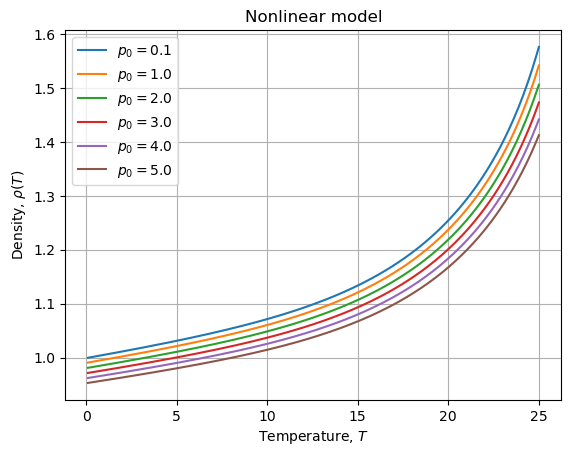

In [50]:
fig, axe = plt.subplots()
for p0 in p0s:
    rho = solve_rho(T, p0)
    axe.plot(T, rho, label=f"$p_0={p0}$")
axe.set_title("Nonlinear model")
axe.set_xlabel("Temperature, $T$")
axe.set_ylabel(r"Density, $\rho(T)$")
axe.legend()
axe.grid()

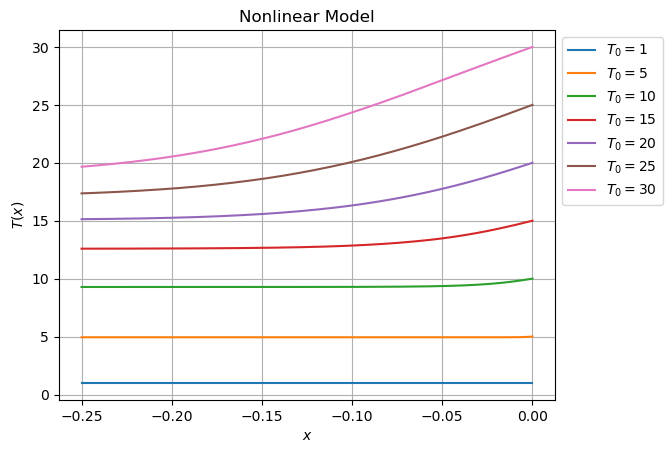

In [15]:
fig, axe = plt.subplots()
for solution, T0 in zip(solutions, T0s):
    axe.plot(solution.t, solution.y.T, label=f"$T_0={T0}$")
axe.set_title("Nonlinear Model")
axe.set_xlabel("$x$")
axe.set_ylabel("$T(x)$")
axe.legend(bbox_to_anchor=(1,1))
axe.grid()